## Projet : Valorisation des comptes rendus clients par le Text Mining

**Phase 1 — Exploration et nettoyage des données**
**Objectif :** Préparer et explorer les comptes rendus clients avant la modélisation.

### Étapes
1. Chargement des données
2. Exploration de la structure
3. Analyse de la qualité des données
4. Détection de la langue des comptes rendus textuels
5. Nettoyage du texte
6. Analyse lexicale
7. Export du dataset nettoyé

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)



In [2]:
df = pd.read_excel(r"C:\Users\yolde\TextMining\data\raw\data_text.xlsx")
df.head()

,ID_Client,Date_Contact,Canal,Compte_Rendu_Text,Code_Motif
0,C_0001,2026-01-03,Application,الحريف زعف من استمرار خصم على التأمين على الحياة رغم ما طلب سدو من خمستاش يوم.,MOTIF_CLOTURE
1,C_0002,2026-04-15,Téléphone,"الحريف هنّى مصلحة مكافحة الاحتيال على اكتشافها السريع لعملية مشبوهة بقيمة 4,150 دينار.",MOTIF_MONETIQUE
2,C_0003,2026-04-26,Téléphone,الحريف زعف من رفض متكرر لبطاقتو رغم وجود رصيد كافي في حساب الطالب متاعو.,MOTIF_MONETIQUE
3,C_0004,2026-03-07,E-mail,الحريف سأل فرع القيروان على المتصفحات المتوافقة مع فضاء الحريف بخصوص حساب لأجل.,MOTIF_DIGITAL
4,C_0005,2026-02-13,Téléphone,الحريف زعف بزاف من تكرار خصم مصاريف على حسابو في فرع القيروان، وهدد ينقل موجوداتو لبنك آخر في أقل من شهر.,MOTIF_FRAIS


In [3]:
print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 4,740
Nombre de colonnes : 5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4740 entries, 0 to 4739
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID_Client          4740 non-null   str           
 1   Date_Contact       4740 non-null   datetime64[us]
 2   Canal              4740 non-null   str           
 3   Compte_Rendu_Text  4740 non-null   str           
 4   Code_Motif         4740 non-null   str           
dtypes: datetime64[us](1), str(4)
memory usage: 185.3 KB


In [5]:
missing = df.isna().sum()

missing_df = pd.DataFrame({
    "Nombre_manquants": missing
})

missing_df

,Nombre_manquants
ID_Client,0
Date_Contact,0
Canal,0
Compte_Rendu_Text,0
Code_Motif,0


## Analyse de la qualité des données

Cette étape permet d'identifier les valeurs manquantes, les doublons et les
éventuelles anomalies avant le nettoyage des comptes rendus textuels.

In [6]:
print("Nombre de lignes dupliquées :", df.duplicated().sum())

Nombre de lignes dupliquées : 0


In [7]:
df.nunique()

ID_Client            1600
Date_Contact          618
Canal                   5
Compte_Rendu_Text    3762
Code_Motif             16
dtype: int64

### Exploration des variables métier

In [8]:
df["Canal"].value_counts()

Canal
Agence         1247
Application    1245
Téléphone      1238
E-mail          983
WhatsApp         27
Name: count, dtype: int64

In [9]:
df["Code_Motif"].value_counts()

Code_Motif
MOTIF_DIGITAL         888
MOTIF_FRAIS           853
MOTIF_CREDIT          812
MOTIF_MONETIQUE       802
MOTIF_RELA_CONSEIL    674
MOTIF_CLOTURE         611
Épargne                17
Compte                 13
Réclamation            11
Carte Bancaire         10
DAB                     9
Crédit                  9
Virement                9
Service Client          9
Application             7
Chèque                  6
Name: count, dtype: int64

In [10]:
df["Date_Contact"].head(10)

0   2026-01-03
1   2026-04-15
2   2026-04-26
3   2026-03-07
4   2026-02-13
5   2026-02-09
6   2026-01-25
7   2026-06-24
8   2026-01-09
9   2026-06-04
Name: Date_Contact, dtype: datetime64[us]

In [11]:
df["text_length"] = df["Compte_Rendu_Text"].fillna("").str.len()

df["text_length"].describe()

count    4740.000000
mean      109.965612
std        27.468340
min        31.000000
25%        91.000000
50%       108.000000
75%       126.000000
max       210.000000
Name: text_length, dtype: float64

In [12]:
df["word_count"] = (
    df["Compte_Rendu_Text"]
    .fillna("")
    .str.split()
    .str.len()
)

df["word_count"].describe()

count    4740.000000
mean       18.277426
std         4.146662
min         6.000000
25%        16.000000
50%        18.000000
75%        21.000000
max        34.000000
Name: word_count, dtype: float64

In [13]:
# Nombre de comptes rendus vides ou constitués uniquement d'espaces

empty_text = (
    df["Compte_Rendu_Text"]
    .fillna("")
    .str.strip()
    .eq("")
)

print("Comptes rendus vides :", empty_text.sum())
print("Pourcentage :", round(empty_text.mean() * 100, 2), "%")

Comptes rendus vides : 0
Pourcentage : 0.0 %


In [14]:
# Vérification des longueurs extrêmes

print("Texte le plus court :")
print(df.loc[df["text_length"].idxmin(), "Compte_Rendu_Text"])

print("\nTexte le plus long :")
print(df.loc[df["text_length"].idxmax(), "Compte_Rendu_Text"])

Texte le plus court :
el client frais barcha b3d dhor

Texte le plus long :
Le client conteste une double facturation des frais de tenue de compte sur deux mois consécutifs et exige un remboursement immédiat, faute de quoi il envisage de porter réclamation auprès de la Banque Centrale.


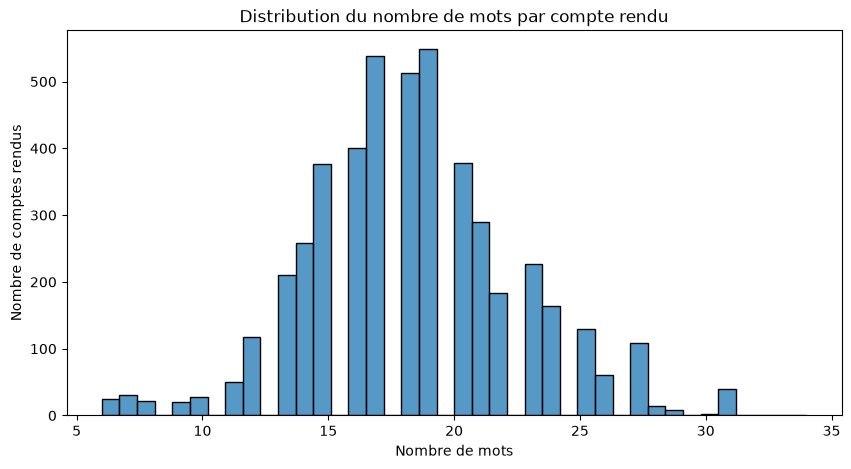

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(df["word_count"], bins=40)

plt.title("Distribution du nombre de mots par compte rendu")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de comptes rendus")

plt.show()

## Détection linguistique

L'objectif est d'identifier la langue dominante de chaque compte rendu.
Le corpus contient principalement du français, de l'arabe et du tunisien
écrit en alphabet latin (TunLat) et autre écrit en arabe (TunAr) .

Une approche hybride est utilisée :
- détection des caractères arabes ;
- détection des marqueurs spécifiques du TunLat ;
- utilisation de `langdetect` pour les textes latins 

In [16]:
sample_texts = df["Compte_Rendu_Text"].sample(
    30,
    random_state=42
)

for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text}")
    print("-" * 100)

1. الحريف كلمنا يلوج على طريقة باش يجدد الكارت تكنولوجيك متاعو. قالي الـ plafond صب وفات وفلوسو تقصت ومحبش يتعدى الشرية الجاية.
----------------------------------------------------------------------------------------------------
2. الحريف حس بخيبة أمل بعد إلغاء موعدو مع المستشار في فرع زغوان بلا سابق إعلام.
----------------------------------------------------------------------------------------------------
3. Le client salue le professionnalisme de son chargé de clientèle, qui a su proposer une solution adaptée pour son compte professionnel.
----------------------------------------------------------------------------------------------------
4. Le client conteste un débit de 25,000 DT qu'il ne reconnaît pas sur sa carte liée à son plan d'épargne retraite et exige une enquête.
----------------------------------------------------------------------------------------------------
5. Client f l'agence très en colère suite à un chèque rejeté pour défaut de provision. Il conteste la pénalité de

In [17]:
ARABIC_RE = re.compile(r"[\u0600-\u06FF]")

def has_arabic(text):
    if pd.isna(text):
        return False
    return bool(ARABIC_RE.search(str(text)))


def has_latin(text):
    if pd.isna(text):
        return False
    return bool(re.search(r"[A-Za-z]", str(text)))

In [18]:
df["has_arabic"] = df["Compte_Rendu_Text"].apply(has_arabic)
df["has_latin"] = df["Compte_Rendu_Text"].apply(has_latin)

print("Contient de l'arabe :", df["has_arabic"].sum())
print("Contient du latin   :", df["has_latin"].sum())

Contient de l'arabe : 1942
Contient du latin   : 3354


In [19]:
cross_lang = pd.crosstab(
    df["has_arabic"],
    df["has_latin"],
    margins=True
)

cross_lang

has_latin,False,True,All
has_arabic,,,
False,0,2798,2798
True,1386,556,1942
All,1386,3354,4740


In [20]:
print("Arabe uniquement :", 
      ((df["has_arabic"]) & (~df["has_latin"])).sum())

print("Latin uniquement :", 
      ((~df["has_arabic"]) & (df["has_latin"])).sum())

print("Arabe + Latin :", 
      ((df["has_arabic"]) & (df["has_latin"])).sum())

print("Ni arabe ni latin :", 
      ((~df["has_arabic"]) & (~df["has_latin"])).sum())

Arabe uniquement : 1386
Latin uniquement : 2798
Arabe + Latin : 556
Ni arabe ni latin : 0


In [21]:
latin_only = df[
    (~df["has_arabic"]) & (df["has_latin"])
]

latin_only[["Compte_Rendu_Text", "Code_Motif"]].sample(
    30,
    random_state=42
)

,Compte_Rendu_Text,Code_Motif
3236,"rabbi ybarek, el fonction ta3 catégorisation el jdida sahhelt 3lia mtabe3a el masrouf ta3 chaher b clarté kbira",MOTIF_DIGITAL
3655,Le client salue la réactivité de l'agence Lac 2 qui a régularisé sans délai les frais contestés.,MOTIF_FRAIS
4552,"Le client demande à quelle heure ferme l'agence le samedi. Simple question pratique, aucune insatisfaction exprimée.",MOTIF_RELA_CONSEIL
1911,"Le client salue le professionnalisme de son directrice d'agence, qui a su proposer une solution adaptée pour son crédit immobilier.",MOTIF_RELA_CONSEIL
2786,Le client signale la perte de sa carte Visa Gold à l'étranger. Demande une mise en opposition immédiate et l'envoi d'une carte de remplacement.,MOTIF_MONETIQUE
2962,Rendez-vous de suivi annuel constructif. Le client se dit pleinement satisfait des performances de son assurance-vie et de la réactivité de son conseiller.,MOTIF_RELA_CONSEIL
2590,Le client signale la perte de sa carte Visa Gold à l'étranger. Demande une mise en opposition immédiate et l'envoi d'une carte de remplacement.,MOTIF_MONETIQUE
3196,Le client exprime son mécontentement suite à une erreur de saisie de son adresse ayant entraîné la perte d'un courrier important lié à son crédit.,MOTIF_CREDIT
2206,Reçu mail mta3 el client y7eb ya3mel rdv m3a el conseiller mta3o bech ychouf simulation de crédit immobilier. Klmto direct w fixit m3ah rdv pour mardi sba7.,MOTIF_CREDIT
2143,Le client est passé en agence pour déposer les pièces justificatives manquantes liées à sa demande de prêt automobile. Dossier complet.,MOTIF_CREDIT


In [22]:
arabic_only = df[
    (df["has_arabic"]) & (~df["has_latin"])
]

arabic_only[["Compte_Rendu_Text", "Code_Motif"]].sample(
    30,
    random_state=42
)

,Compte_Rendu_Text,Code_Motif
649,الحريف اشتكى من تعقيد الوثائق المطلوبة لـبطاقة الائتمان، شافها ما تتناسبش مع قيمة المبلغ المطلوب.,MOTIF_CREDIT
208,الحريف سأل على خطوات تبديل العونة التجارية متاعو في فرع القيروان.,MOTIF_RELA_CONSEIL
945,"الحريف زعف من مصاريف 28,750 دينار تحاسب بيها وقت سد التأمين على الحياة، ما كانوش متوقعين وقت الفتح.",MOTIF_CLOTURE
678,الحريف عبّر على رضاه من تسيير سد القرض العقاري متاعو بلا مشكل بعد تغيير وضعيتو.,MOTIF_CLOTURE
802,الحريف هنّى مهنية مسؤول الحساب اللي عرف يقترح حل مناسب بخصوص الحساب المهني.,MOTIF_RELA_CONSEIL
239,الحريف شكر فرع منوبة على سد القرض العقاري متاعو بسرعة في خمسة أسابيع بلا أي عراقيل.,MOTIF_CLOTURE
817,"الحريف حكى بلي حوالة بـ18,600 دينار عملها من التطبيق باقية في حالة انتظار من خمسة أسابيع.",MOTIF_DIGITAL
527,الحريف انبهر بوضوح تفسيرات مدير الفرع خلال محاكاة الحساب الجاري متاعو.,MOTIF_CREDIT
721,الحريف قدّر المرونة اللي عطاها العون التجاري في فرع المهدية باش يزيد سقف الدفع قبل سفرو.,MOTIF_MONETIQUE
3132,الحريف جدد عقد التأمين على القرض بلا أي تعقيد، شكر العون على سرعة المعالجة ووضوح الشروط المقترحة,MOTIF_CREDIT


In [23]:
mixed = df[
    (df["has_arabic"]) & (df["has_latin"])
]

mixed[["Compte_Rendu_Text", "Code_Motif"]].sample(
    30,
    random_state=42
)

,Compte_Rendu_Text,Code_Motif
4218,الحريف من فرع Menzah 6 يشتكي من حجز الـ Mastercard متاعو من تلاتة ايام بلا تفسير.,MOTIF_MONETIQUE
2683,Appel du client : y7eb ya3mel virement de compte à compte w ma 3رفش كيفاش f l'application. Ena fassartlo les étapes w 3اونتو bech ykamel l'opération.,MOTIF_DIGITAL
2234,El client 3mal réclamation 3al carte Visa mte3o li tسرقت. Il demande blocage w renouvellement fi a9rab wa9t.,MOTIF_MONETIQUE
3061,الحريفة جات تشتكي إنها دفعت مرتين نفس القسط ديال القرض بسبب bug في النظام، تطلب استرجاع المبلغ الزايد بسرعة,MOTIF_CREDIT
2276,Appel du client : y7eb ya3mel virement de compte à compte w ma 3رفش كيفاش f l'application. Ena fassartlo les étapes w 3اونتو bech ykamel l'opération.,MOTIF_DIGITAL
3970,الحريف غاضب لأن السقف اليومي للـ Visa Gold متاعو ما يكفيش، ضيّع صفقة مهمة بسبب هذا.,MOTIF_MONETIQUE
4073,الحريف يطلب أرقام التواصل المباشر مع الكونساي الجديد متاعو بعد التغيير في فرع Ennasr.,MOTIF_RELA_CONSEIL
2314,الحريف كلمنا يلوج على طريقة باش يجدد الكارت تكنولوجيك متاعو. قالي الـ plafond صب وفات وفلوسو تقصت ومحبش يتعدى الشرية الجاية.,MOTIF_MONETIQUE
4392,Client mte3 agence Sfax Centre y7eb ya3raf tafsil el frais eli tsajlou 3al compte mte3o men تلاتة ايام.,MOTIF_FRAIS
4295,الحريف يشتكي من agios بقيمة 30 دينار تقصتلو من دون سابق إعلام. قالي راهو رح يسكر الكونط.,MOTIF_FRAIS


In [24]:
import re
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

ARABIC_RE = re.compile(r'[\u0600-\u06FF]')
LATIN_RE = re.compile(r'[A-Za-zÀ-ÿ]')

# Mots caractéristiques du tunisien écrit en latin
TUNLAT_MARKERS = {
    'el', 'elli', 'fama', 'fi', 'ma', 'mouch', 'moch', 'ma3adech',
    'y9oul', 'y7eb', 'yesta', 'yestaفسر', 'ychki', 'yطلب',
    't3awed', 'ta3mel', 't5dem', 'taw', 'mazel', 'yestanna',
    'lmochkel', 'mochkel', 'srii3', 'tawdhi7', '7al',
    '3la', '3lech', '5ater', 'ba3d', 'barcha', 'm3a',
    'ma3', 'ynajjem', 'yconfirmi', 'yetchaf', 'dossier',
    'mte3ou', 'mte3', 'zeydin', 't9ayedch', 'ywaselch'
}

# Mots latins courants qui peuvent apparaître dans du TunAr
# sans rendre le texte réellement mixte
COMMON_LATIN_WORDS = {
    'application', 'app', 'service', 'client', 'réponse',
    'suivi', 'intervention', 'dossier', 'carte', 'code',
    'operation', 'opération', 'virement', 'retrait',
    'compte', 'frais', 'cheque', 'chèque'
}


def detect_langue(text):
    text = str(text).strip()

    # Présence des deux alphabets
    has_arabic = bool(ARABIC_RE.search(text))
    has_latin = bool(LATIN_RE.search(text))

    # Extraction des mots
    words = re.findall(r'\b[\wÀ-ÿ]+\b', text.lower())

    # Mots caractéristiques du tunisien latin
    tunlat_words = [
        w for w in words
        if w in TUNLAT_MARKERS
        or any(char.isdigit() for char in w)
    ]

    # Cas arabe + véritable présence de TunLat
    if has_arabic and len(tunlat_words) >= 1:
        return "Mixte"

    # Texte arabe avec quelques mots latins génériques
    if has_arabic and has_latin:
        return "TunAr"

    # Texte avec marqueurs TunLat
    if len(tunlat_words) >= 1:
        return "TunLat"

    # Sinon, détection du français
    try:
        lang = detect(text)

        if lang == 'fr':
            return "Français"
    except:
        pass

    # Si principalement arabe
    if has_arabic:
        return "TunAr"

    # Par défaut
    return "Français"

detecter_langue = detect_langue


In [25]:
df["Langue"] = df["Compte_Rendu_Text"].apply(detect_langue)

print(df["Langue"].value_counts())

Langue
TunAr       1414
Français    1405
TunLat      1393
Mixte        528
Name: count, dtype: int64


In [26]:
for langue in ["Français", "TunAr", "TunLat", "Mixte"]:
    print("\n" + "="*60)
    print("LANGUE :", langue)
    print("="*60)

    print(
        df[df["Langue"] == langue][
            ["Compte_Rendu_Text", "Code_Motif"]
        ].sample(10, random_state=42)
    )


LANGUE : Français
                                                                                                                                                Compte_Rendu_Text  \
3645                                              Le client remercie l'agence Bizerte pour le remplacement express de sa Visa Classic en seulement deux semaines.   
1655                                          Le client demande le délai nécessaire pour finaliser la clôture de son compte joint ouvert depuis plusieurs années.   
1849                                     Le client demande à son gestionnaire de compte le plafond de paiement en ligne actuellement fixé sur son compte à terme.   
1855                                      Le client se renseigne auprès de Jendouba sur les navigateurs compatibles avec l'espace client pour son carte de débit.   
2784  Rendez-vous de suivi annuel constructif. Le client se dit pleinement satisfait des performances de son assurance-vie et de la réactivité de son consei

In [27]:
test_texts = [
    "Le client précise un problème concernant rejet de chèque.",
    "el client y9oul elli l application t3awed ta3mel logout w y7eb 7al srii3.",
    "الحريف يوضح اللي فما إشكال في الملف تعطل برشة.",
    "el client talab توضيح 3la fama mochkel m3a l carte.",
    "Le client souhaite une vérification de son dossier.",
    "الحريف ما عادش ينجم السحب ترفض ويحب حل سريع."
]

for i, text in enumerate(test_texts, 1):
    print(f"{i}. {detecter_langue(text)}")
    print(text)
    print("-" * 80)

1. Français
Le client précise un problème concernant rejet de chèque.
--------------------------------------------------------------------------------
2. TunLat
el client y9oul elli l application t3awed ta3mel logout w y7eb 7al srii3.
--------------------------------------------------------------------------------
3. TunAr
الحريف يوضح اللي فما إشكال في الملف تعطل برشة.
--------------------------------------------------------------------------------
4. Mixte
el client talab توضيح 3la fama mochkel m3a l carte.
--------------------------------------------------------------------------------
5. TunLat
Le client souhaite une vérification de son dossier.
--------------------------------------------------------------------------------
6. TunAr
الحريف ما عادش ينجم السحب ترفض ويحب حل سريع.
--------------------------------------------------------------------------------


In [28]:
df["Langue"] = df["Compte_Rendu_Text"].apply(detecter_langue)

In [29]:
df["Langue"].value_counts()

Langue
TunAr       1414
Français    1405
TunLat      1393
Mixte        528
Name: count, dtype: int64

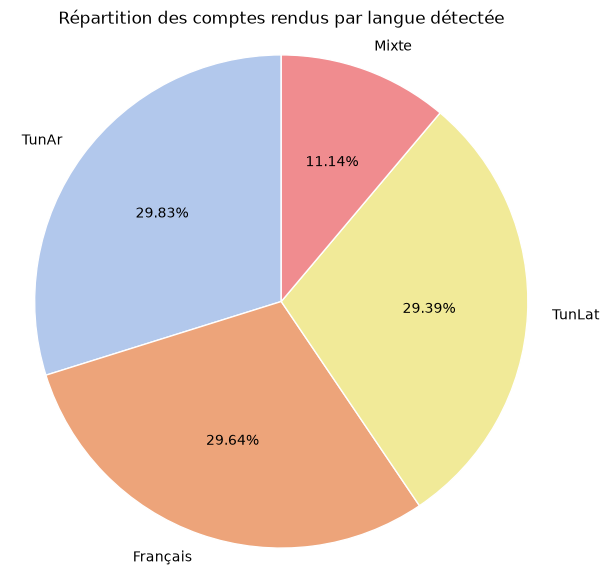

In [30]:
import matplotlib.pyplot as plt

langue_pct = df["Langue"].value_counts(normalize=True).mul(100).round(2)

colors = ["#B2C8EC", "#EDA47A", "#F1EA98", "#F08C8F"]

plt.figure(figsize=(7, 7))
plt.pie(
    langue_pct,
    labels=langue_pct.index,
    autopct="%.2f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("Répartition des comptes rendus par langue détectée")
plt.axis("equal")
plt.show()

In [31]:
for langue in ["Français", "TunLat", "TunAr", "Mixte"]:
    print(f"\n{'='*60}")
    print(f"LANGUE : {langue}")
    print(f"{'='*60}")
    
    display(
        df[df["Langue"] == langue][
            ["Compte_Rendu_Text", "Code_Motif"]
        ].sample(
            min(10, (df["Langue"] == langue).sum()),
            random_state=42
        )
    )


LANGUE : Français


,Compte_Rendu_Text,Code_Motif
3645,Le client remercie l'agence Bizerte pour le remplacement express de sa Visa Classic en seulement deux semaines.,MOTIF_MONETIQUE
1655,Le client demande le délai nécessaire pour finaliser la clôture de son compte joint ouvert depuis plusieurs années.,MOTIF_CLOTURE
1849,Le client demande à son gestionnaire de compte le plafond de paiement en ligne actuellement fixé sur son compte à terme.,MOTIF_MONETIQUE
1855,Le client se renseigne auprès de Jendouba sur les navigateurs compatibles avec l'espace client pour son carte de débit.,MOTIF_DIGITAL
2784,Rendez-vous de suivi annuel constructif. Le client se dit pleinement satisfait des performances de son assurance-vie et de la réactivité de son conseiller.,MOTIF_RELA_CONSEIL
1449,Le client félicite Sousse Sud pour l'accompagnement lors de l'activation de la signature électronique sur son assurance vie.,MOTIF_DIGITAL
3953,"Le client remercie Mme Bouazizi pour la clôture rapide et sans frais de son ancien compte, traitée en un mois.",MOTIF_CLOTURE
1142,Le client se dit impressionné par la clarté des explications de son directeur d'agence lors de la simulation de son assurance vie.,MOTIF_CREDIT
1100,Le client demande une simulation des frais annuels liés à son livret d'épargne auprès de l'agence de Nabeul.,MOTIF_FRAIS
1974,Le client félicite Menzel Bourguiba pour l'accompagnement lors de l'activation de la signature électronique sur son carte de débit.,MOTIF_DIGITAL



LANGUE : TunLat


,Compte_Rendu_Text,Code_Motif
2236,Frais barcha 3al compte courant w ena ma nesta3mloch dima. Ken bech tkamlo haka bech nbadal el banka o5ra.,MOTIF_FRAIS
3772,Le client s'est présenté en agence Sfax Centre pour dénoncer une facturation de 15 DT qu'il estime injustifiée. Ton agressif.,MOTIF_FRAIS
3529,el client virement mazel pending bravofi agence,Virement
2787,"Demande d'informations concernant les conditions d'octroi d'un crédit immobilier (taux d'intérêt, durée maximale, autofinancement requis). Dossier transmis au chef d'agence.",MOTIF_CREDIT
3076,Le client conteste fermement des frais de gestion de dossier de succession qu'il juge excessifs par rapport à ce qui lui avait été annoncé initialement.,MOTIF_FRAIS
2878,Le client est passé en agence pour déposer les pièces justificatives manquantes liées à sa demande de prêt automobile. Dossier complet.,MOTIF_CREDIT
4423,Le client demande des explications sur des frais de 250 DT apparus sur son relevé ce matin. Dossier transmis pour vérification.,MOTIF_FRAIS
2066,Frais barcha 3al compte courant w ena ma nesta3mloch dima. Ken bech tkamlo haka bech nbadal el banka o5ra.,MOTIF_FRAIS
2474,Brabi n7eb nclori el compte mte3i 5ater el frais de tenue de compte walat ghalia barcha w ma3adech nesta3mel fih. Chnouma el bwra9 el matloubin?,MOTIF_CLOTURE
1172,"Le client exprime son inquiétude face à une majoration de 25,000 DT appliquée sur son plan d'épargne retraite sans justification claire.",MOTIF_CREDIT



LANGUE : TunAr


,Compte_Rendu_Text,Code_Motif
2036,مطلب قرض استهلاكي لشراء سيارة مستعملة. الأوراق كاملة والملف تعدّى للـ comité des engagements باش ياخذو القرار الجمعة الجاية.,MOTIF_CREDIT
2419,الحريف جا للفرع غاضب على خاطر تقصتلو خطية متع شيك بدون رصيد. يطالب يقابل الشيف دآجونس باش ينحيلو الفراي.,MOTIF_FRAIS
412,الحريف سأل المستشار على سقف الدفع أونلاين المفعّل حاليا على حساب لأجل متاعو.,MOTIF_MONETIQUE
229,الحريف انبهر بوضوح تفسيرات المستشارة خلال محاكاة التأمين على المسكن متاعو.,MOTIF_CREDIT
242,الحريف اشتكى من تأخير ستة أسابيع في سد حساب لأجل متاعو، بلا تأكيد كتابي من فرع قابس.,MOTIF_CLOTURE
971,الحريف سأل فرع المهدية على المتصفحات المتوافقة مع فضاء الحريف بخصوص الحساب المشترك.,MOTIF_DIGITAL
663,الحريف سأل مسؤول الحساب في فرع جربة على تفاصيل المصاريف السنوية المطبقة على قرض السيارة.,MOTIF_FRAIS
77,الحريف فرحان بالخاصية الجديدة اللي تخليه يتابع حركات دفتر التوفير متاعو في الوقت الحقيقي.,MOTIF_DIGITAL
2654,الحريف يشتكي من قلة احترام العون في فرع تونس. قال دخلت وموش لاهين بيا وخلاوني نستنى ساعة كاملة على جرد صبّان شكّ.,MOTIF_RELA_CONSEIL
60,الحريف هنّى فرع المرسى على خاطر سوّى مشكل مصاريف غلط في حوالي عشرين يوم بس.,MOTIF_FRAIS



LANGUE : Mixte


,Compte_Rendu_Text,Code_Motif
818,"الحريف طلب رد 11,900 دينار من المصاريف اللي يشوفها ظالمة، تحسبت بلا سابق إعلام على قرض السيارة متاعو في المنستير.",MOTIF_FRAIS
3979,"Client far7an b rapidité clôture compte mte3o, 9al el opération saret f 15 يوم bark.",MOTIF_CLOTURE
40,"الحريف عبّر على قلقو من زيادة 25,000 دينار تحسبت على القرض العقاري متاعو بلا تفسير واضح.",MOTIF_CREDIT
4040,الحريف يسأل على سبب فراي بـ 40 دينار ظهرلو في الكشف. الملف تحول للفحص.,MOTIF_FRAIS
456,"الحريف هنّى العونة التجارية على الموافقة السريعة في ثلاثة أسابيع على الحساب المهني بقيمة 14,900 دينار.",MOTIF_CREDIT
2240,Appel du client : y7eb ya3mel virement de compte à compte w ma 3رفش كيفاش f l'application. Ena fassartlo les étapes w 3اونتو bech ykamel l'opération.,MOTIF_DIGITAL
4496,الحريف من فرع El Manar شكر Mme Trabelsi على تبديل الـ carte technologique في تلاتة ايام بارك.,MOTIF_MONETIQUE
4352,Client y9oul comité des engagements ma 3tawlouch réponse 3la demande قرض السيارة mnou depuis شهر.,MOTIF_CREDIT
3642,الحريف غاضب برشة على خاطر تقصتلو خطية بـ 55 دينار متع شيك بدون رصيد. يطالب يقابل الشيف باش ينحيلو الفراي.,MOTIF_FRAIS
564,"الحريف اكتشف خصم 1,200 دينار ما يعرفوش على بطاقتو المرتبطة بـحساب لأجل وطلب تحقيق فوري.",MOTIF_MONETIQUE


## Nettoyage du texte

Pipeline appliqué à chaque compte rendu, en tenant compte des 4 langues détectées (Français, TunLat, TunAr, Mixte) :

1. **Suppression des URLs**
2. **Segmentation** — découpage en mots (tokenisation)
3. **Suppression des chiffres**, sauf pour TunLat où les chiffres encodent des lettres arabes (ex: `3`=ع, `7`=ح, `9`=ق, `5`=خ) et doivent donc être conservés à l'intérieur des mots
4. **Lemmatisation** avec **CAMeL Tools** (qui n'analyse que le script arabe) :
   - mots en script arabe → lemmatisés directement
   - mots en arabizi (latin) → **translittérés en arabe** puis lemmatisés ; si aucune analyse n'est trouvée (mot dialectal absent du lexique standard), le mot arabizi original est conservé tel quel
   
5. **Normalisation**



In [32]:
# Installation des dépendances de nettoyage
!pip install --quiet emoji camel-tools
!camel_data -i morphology-db-msa-r13


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


No new packages will be installed.


In [33]:
import camel_tools
print(camel_tools.__version__)

1.6.0


In [ ]:
import re
from camel_tools.utils.normalize import (
    normalize_unicode,
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_teh_marbuta_ar,
)
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

# Base morphologique CAMeL Tools (arabe standard, utilisable aussi sur du tunisien écrit en arabe)
_db = MorphologyDB.builtin_db("calima-msa-r13")
_analyzer = Analyzer(_db)

ARABIC_RE = re.compile(r"[\u0600-\u06FF]")
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
DIACRITICS_RE = re.compile(r"[\u064B-\u0652]")

# Mots vides courants (français + tunisien) à retirer après segmentation
STOPWORDS = {
    "le", "la", "les", "un", "une", "des", "de", "du", "et", "à", "au", "aux","y","en",
    "el", "la3", "ya", "wl", "w","3al","3ala","ala","o","w","wala","walla","lel","li","el",
}

# Marqueurs arabizi (dupliqués ici pour que cette section soit autonome,
# indépendamment de la section "Détection linguistique" plus haut dans le notebook)
TUNLAT_MARKERS = {
    "el", "elli", "fama", "fi", "ma", "mouch", "moch", "ma3adech",
    "y9oul", "y7eb", "yesta", "ychki",
    "t3awed", "ta3mel", "t5dem", "taw", "mazel", "yestanna",
    "lmochkel", "mochkel", "srii3", "tawdhi7", "7al",
    "3la", "3lech", "5ater", "ba3d", "barcha", "m3a",
    "ma3", "ynajjem", "yconfirmi", "yetchaf", "zeyda",
    "mte3ou", "mte3", "zeydin", "t9ayedch", "ywaselch","chwaya",
}


def supprimer_urls(text):
    """Étape 1 : suppression des URLs."""
    return URL_RE.sub(" ", text)




def segmenter(text):
    """Étape 3 : segmentation en mots (tokenisation)."""
    return re.findall(r"[\wÀ-ÿ]+", text.lower())


def est_token_arabizi(token):
    """Un chiffre au milieu de lettres latines encode un son arabe (3la, 7al, y9oul...)."""
    return bool(re.search(r"[a-zà-ÿ]", token)) and bool(re.search(r"\d", token))


def supprimer_chiffres(tokens):
    """Étape 4 : suppression des chiffres, sauf pour les tokens arabizi(TunAr)."""
    out = []
    for t in tokens:
        if est_token_arabizi(t):
            out.append(t)  # on garde : ce sont des lettres arabes encodées en chiffres
        elif t.isdigit():
            continue  # nombre pur (montant, code, date...) : on supprime
        else:
            out.append(t)
    return out


# --- Translittération arabizi -> arabe (chat-alphabet approximatif) ---

_DIGRAPHES_AR = {"kh": "خ", "gh": "غ", "ch": "ش", "sh": "ش", "th": "ث", "dh": "ذ"}

_CHIFFRES_AR = {"2": "ء", "3": "ع", "5": "خ", "6": "ط", "7": "ح", "8": "ق", "9": "ق"}

_LETTRES_AR = {
    "a": "ا", "b": "ب", "c": "ك", "d": "د", "e": "ي", "f": "ف", "g": "ڨ",
    "h": "ه", "i": "ي", "j": "ج", "k": "ك", "l": "ل", "m": "م", "n": "ن",
    "o": "و", "p": "ب", "q": "ق", "r": "ر", "s": "س", "t": "ت", "u": "و",
    "v": "ف", "w": "و", "x": "كس", "y": "ي", "z": "ز",
}

_LETTRES_ARABES_VALIDES = set("خشغثذعءحطقكبدفڨهجلمنورستزي")


def translitterer_arabizi(token):
    """Convertit un token arabizi (latin + chiffres) en arabe, de façon approximative."""
    t = token.lower()
    for k, v in _DIGRAPHES_AR.items():
        t = t.replace(k, v)
    out = []
    for ch in t:
        if ch in _CHIFFRES_AR:
            out.append(_CHIFFRES_AR[ch])
        elif ch in _LETTRES_AR:
            out.append(_LETTRES_AR[ch])
        elif ch in _LETTRES_ARABES_VALIDES:
            out.append(ch)
    # dédoublonnage des lettres consécutives identiques
    # (les voyelles latines créent des doublons artificiels absents en arabe non voyellé)
    dedup = []
    for ch in out:
        if not dedup or dedup[-1] != ch:
            dedup.append(ch)
    return "".join(dedup)


def lemmatiser(token):
    """Étape 6 : lemmatisation de l'arabe/arabizi avec CAMeL Tools.
    - Script arabe -> lemmatisation directe.
    - Arabizi (latin) -> translittération puis lemmatisation ; si aucune analyse
      n'est trouvée, le token arabizi original est conservé.
    - Autres tokens latins (déjà lemmatisés par spaCy s'ils étaient français) -> inchangés.
    """
    if ARABIC_RE.search(token):
        analyses = _analyzer.analyze(token)
        if analyses:
            return DIACRITICS_RE.sub("", analyses[0].get("lex", token))
        return token

    if est_token_arabizi(token) or token in TUNLAT_MARKERS:
        token_ar = translitterer_arabizi(token)
        if token_ar:
            analyses = _analyzer.analyze(token_ar)
            if analyses:
                return DIACRITICS_RE.sub("", analyses[0].get("lex", token_ar))
        return token  # pas d'analyse trouvée : on garde l'arabizi d'origine

    return token


def normaliser_token(token):
    """Étape 6 : normalisation des variantes d'écriture."""
    if ARABIC_RE.search(token):
        t = normalize_unicode(token)
        t = normalize_alef_ar(t)
        t = normalize_alef_maksura_ar(t)
        t = normalize_teh_marbuta_ar(t)
        return t
    # latin / arabizi : réduction des lettres répétées (ex. "aaah" -> "aah")
    return re.sub(r"(.)\1{2,}", r"\1\1", token)


def nettoyer_texte(text):
    """Pipeline complet de nettoyage, retourne la liste des tokens nettoyés."""
    text = supprimer_urls(str(text))
    text = supprimer_emojis(text)
    tokens = segmenter(text)
    tokens = supprimer_chiffres(tokens)
    tokens = [t for t in tokens if t not in STOPWORDS]
    tokens = [lemmatiser(t) for t in tokens]
    tokens = [normaliser_token(t) for t in tokens]
    return [t for t in tokens if t]



In [35]:
# Application du pipeline à l'ensemble du corpus
df["Tokens"] = df["Compte_Rendu_Text"].apply(nettoyer_texte)
df["Compte_Rendu_Clean"] = df["Tokens"].apply(lambda toks: " ".join(toks))

df[["Compte_Rendu_Text", "Compte_Rendu_Clean", "Langue"]].sample(10, random_state=42)

,Compte_Rendu_Text,Compte_Rendu_Clean,Langue
2313,الحريف كلمنا يلوج على طريقة باش يجدد الكارت تكنولوجيك متاعو. قالي الـ plafond صب وفات وفلوسو تقصت ومحبش يتعدى الشرية الجاية.,حريف كلم يلوج علي طريقه باش اجد كارت تكنولوجي متاعو قالي ال plafond صب فات وفلوسو تقصي ومحبش تعدي الشريه الجايه,TunAr
354,الحريف حس بخيبة أمل بعد إلغاء موعدو مع المستشار في فرع زغوان بلا سابق إعلام.,حريف حس خيبه امل بعد الغاء موعدو مع مستشار في فرع زغوان بل سابق اعلام,TunAr
1397,"Le client salue le professionnalisme de son chargé de clientèle, qui a su proposer une solution adaptée pour son compte professionnel.",client salue professionnalisme son chargé clientèle qui a su proposer solution adaptée pour son compte professionnel,Français
1846,"Le client conteste un débit de 25,000 DT qu'il ne reconnaît pas sur sa carte liée à son plan d'épargne retraite et exige une enquête.",client conteste débit dt qu il ne reconnaît pas sur sa carte liée son plan d épargne retraite exige enquête,TunLat
2830,Client f l'agence très en colère suite à un chèque rejeté pour défaut de provision. Il conteste la pénalité de retard facturée par la banque.,client f l agence très colère suite chèque rejeté pour défaut provision il conteste pénalité retard facturée par banque,Français
227,الحريف قدّر المرونة اللي عطاها العونة التجارية في فرع الحمامات باش يزيد سقف الدفع قبل سفرو.,حريف قد ر مرونه لي عطا العونه تجاري في فرع حمام باش زيد سقف دفع قبل سفرو,TunAr
1102,"Le client est satisfait du geste commercial accordé par son chargée de clientèle, correspondant à un remboursement de 3,450 DT.",client est satisfait geste commercial accordé par son chargée clientèle correspondant remboursement dt,TunLat
1187,"Le client dénonce l'échec répété de ses connexions à l'espace client pour gérer son compte devises, un problème non résolu depuis trois semaines.",client dénonce l échec répété ses connexions l espace client pour gérer son compte devises problème non résolu depuis trois semaines,Français
3370,"walahi metghadheb, appli tsakret 3lia w rj3et lel écran login kol 5 da9ay9, mab9itch najem ne5dam behi",walahi metghadheb appli tsakret علي rj3et écran login kol da9ay9 mab9itch najem ne5dam behi,TunLat
1803,Le client remercie Manouba pour l'envoi rapide de sa nouvelle carte suite à sa perte à Médenine.,client remercie manouba pour l envoi rapide sa nouvelle carte suite sa perte médenine,Français


In [36]:
# Contrôle : nombre de mots avant / après nettoyage
df["word_count_clean"] = df["Tokens"].apply(len)

print(df[["word_count", "word_count_clean"]].describe())


        word_count  word_count_clean
count  4740.000000       4740.000000
mean     18.277426         15.875949
std       4.146662          3.343242
min       6.000000          4.000000
25%      16.000000         14.000000
50%      18.000000         16.000000
75%      21.000000         18.000000
max      34.000000         27.000000


In [37]:
# Vérification du texte le plus court : a-t-il perdu des mots au nettoyage ?
idx_min = df["word_count"].idxmin()

print("Texte brut le plus court (word_count =", df.loc[idx_min, "word_count"], ") :")
print(df.loc[idx_min, "Compte_Rendu_Text"])
print()
print("Langue détectée :", df.loc[idx_min, "Langue"])
print()
print("Tokens après nettoyage (", df.loc[idx_min, "word_count_clean"], "mots ) :")
print(df.loc[idx_min, "Tokens"])
print()
print("Texte nettoyé reconstruit :")
print(df.loc[idx_min, "Compte_Rendu_Clean"])

# Bonus : combien de comptes rendus n'ont perdu STRICTEMENT aucun mot au nettoyage ?
non_reduits = (df["word_count"] == df["word_count_clean"]).sum()
print(f"\nComptes rendus sans aucune réduction de mots : {non_reduits} ({non_reduits / len(df) * 100:.1f} %)")

Texte brut le plus court (word_count = 6 ) :
el client credit t2akher elyoumfi agence

Langue détectée : TunLat

Tokens après nettoyage ( 5 mots ) :
['client', 'credit', 't2akher', 'elyoumfi', 'agence']

Texte nettoyé reconstruit :
client credit t2akher elyoumfi agence

Comptes rendus sans aucune réduction de mots : 1189 (25.1 %)


In [38]:
import os

os.chdir(r"C:\Users\yolde\TextMining\notebooks")

print(os.getcwd())

C:\Users\yolde\TextMining\notebooks


In [39]:
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/data_text_nettoyes.csv", index=False)

print("Fichier sauvegardé : data/processed/data_text_nettoyes.csv")

Fichier sauvegardé : data/processed/data_text_nettoyes.csv


In [40]:
!pip install wordcloud arabic-reshaper python-bidi -q

from wordcloud import WordCloud
import numpy as np
import re
import os
import urllib.request
import arabic_reshaper
from bidi.algorithm import get_display


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Police compatible avec l'arabe
FONT_PATH = "NotoNaskhArabic-Regular.ttf"

if not os.path.exists(FONT_PATH):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/google/fonts/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf",
        FONT_PATH
    )


def prepare_text_for_cloud(text):
    """Prépare les mots arabes pour un affichage correct."""
    
    words_out = []
    
    for w in text.split():
        if re.search(r"[\u0600-\u06FF]", w):
            w = get_display(arabic_reshaper.reshape(w))
        
        words_out.append(w)
    
    return " ".join(words_out)

In [42]:
def generate_wordcloud_langue(
    df,
    langue,
    colormap="viridis",
    contour_color="steelblue"
):

    # Filtrer la langue
    df_langue = df[df["Langue"] == langue]

    # Récupérer le texte nettoyé
    text_langue = " ".join(
        df_langue["Compte_Rendu_Clean"]
        .dropna()
        .apply(prepare_text_for_cloud)
    )

    # Masque circulaire
    x, y = np.ogrid[:800, :800]

    mask = (
        (x - 400) ** 2 +
        (y - 400) ** 2
        > 390 ** 2
    )

    mask = 255 * mask.astype(int)

    # Création du WordCloud
    wc_langue = WordCloud(
        width=1600,
        height=1600,
        background_color="white",
        mask=mask,
        colormap=colormap,
        max_words=150,
        min_font_size=10,
        contour_width=2,
        contour_color=contour_color,
        prefer_horizontal=0.9,
        random_state=42,
        collocations=False,
        font_path=FONT_PATH
    ).generate(text_langue)

    # Affichage
    plt.figure(figsize=(10, 10))

    plt.imshow(
        wc_langue,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"Nuage de mots - {langue}",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    plt.show()

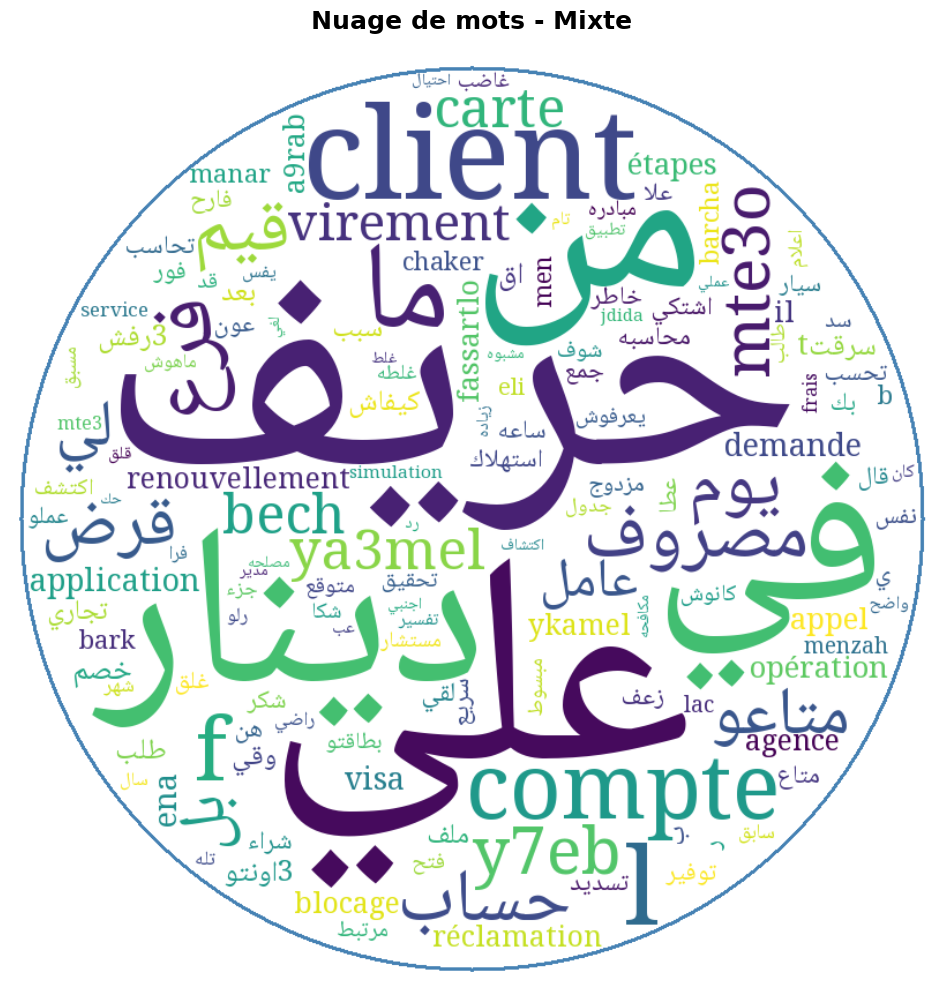

In [43]:
generate_wordcloud_langue(
    df,
    langue="Mixte",
    colormap="viridis",
    contour_color="steelblue"
)

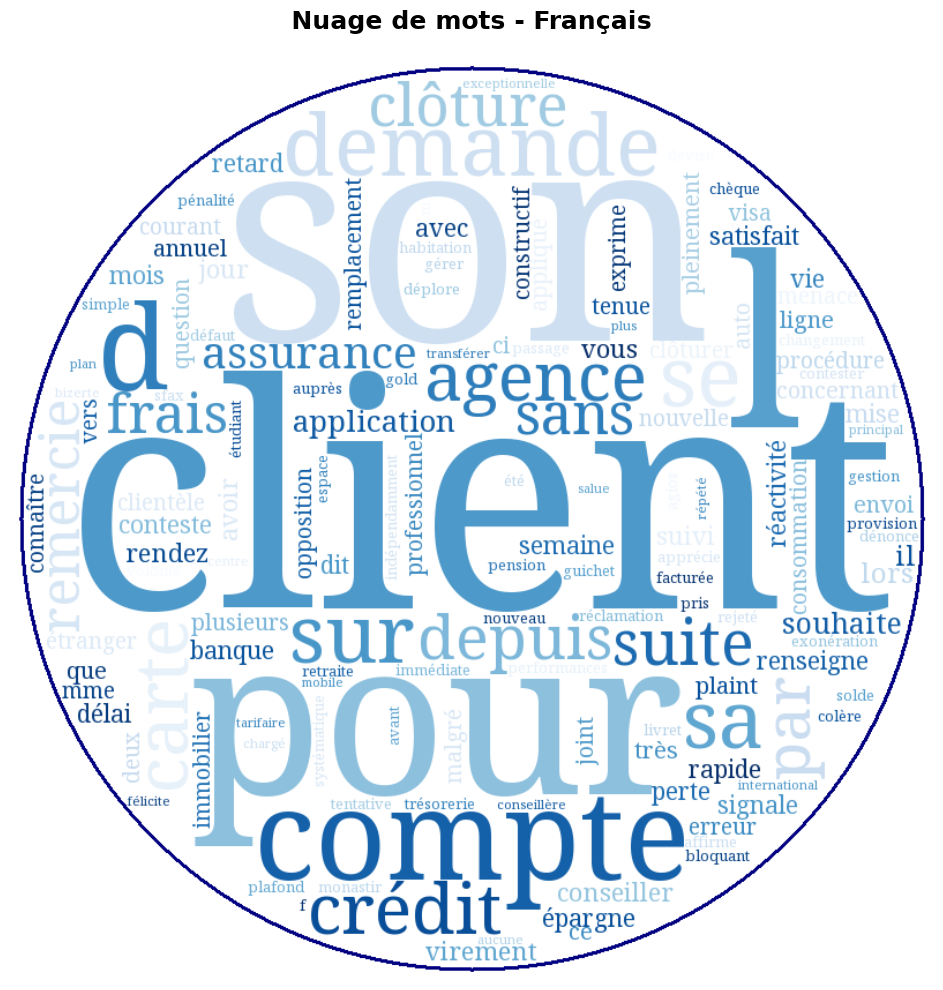

In [44]:
generate_wordcloud_langue(
    df,
    langue="Français",
    colormap="Blues",
    contour_color="navy"
)

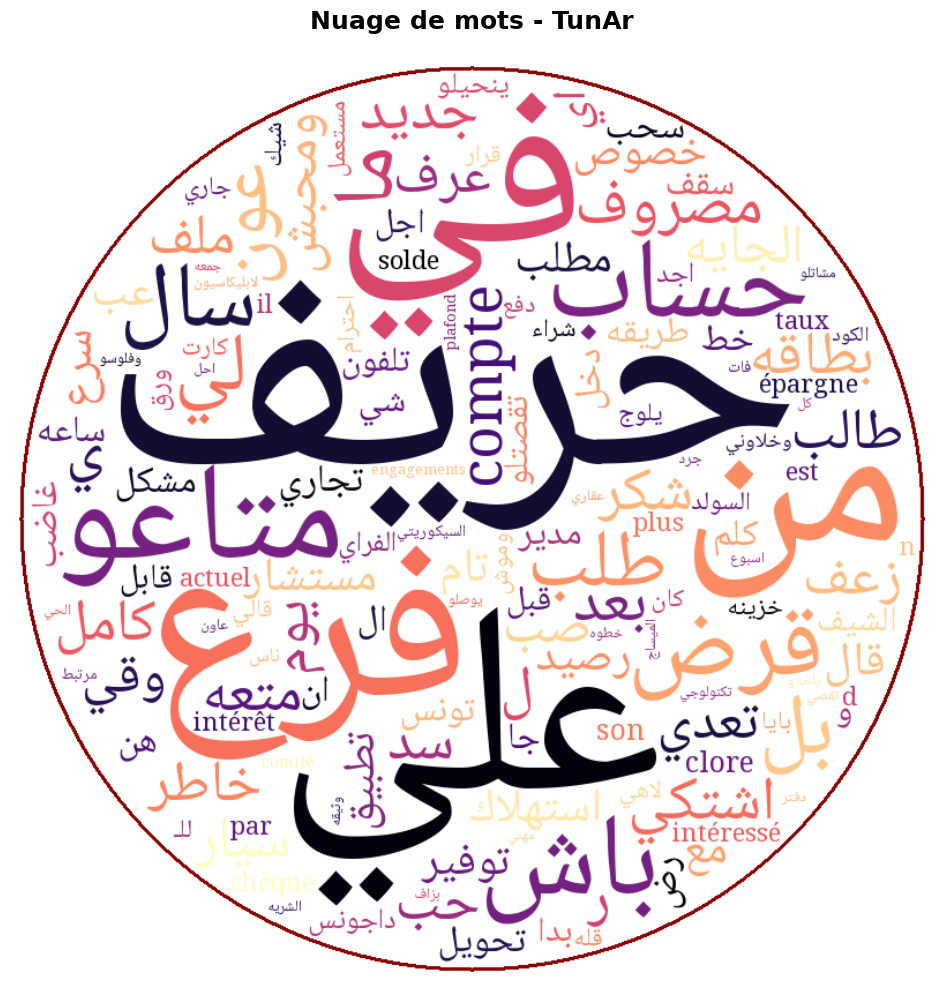

In [45]:
generate_wordcloud_langue(
    df,
    langue="TunAr",
    colormap="magma",
    contour_color="darkred"
)